<a href="https://colab.research.google.com/github/fasilabeeviak-stack/Colab-Project/blob/main/PROJECT_ba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

## Load Data

In [ ]:
df_train = pd.read_csv('/content/train.tsv', sep='\t')
display(df_train.head())

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


## Create a Sample Subset of Training Data

To speed up experimentation and model benchmarking, a sample subset of the training data (`df_train`) will be created. This allows for quicker iteration cycles while developing and testing new features or model configurations.

In [ ]:
# Create a 10% sample of the training data
df_train_sample = df_train.sample(frac=0.1, random_state=42)

print(f"Shape of the sampled training data: {df_train_sample.shape}")
print("Sampled training data head:")
display(df_train_sample.head())

Shape of the sampled training data: (148254, 24)
Sampled training data head:


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,price_log,main_category,...,main_category_encoded,sub_category_encoded,sub_sub_category_encoded,has_limited_edition,has_rare,has_vintage,has_new_with_tags,has_damaged,has_broken,has_collectible
777341,777341,F/ship 4 Totoro Washi + 1 pen,1,Handmade/Paper Goods/Stationery,missing,12.0,1,This listing is for all 4 Totoro washi tape fo...,2.564949,Handmade,...,2,77,729,0,0,0,0,0,0,0
1463629,1463629,UCLA Men's Bundle + Shorts,1,Women/Other/Other,Adidas,76.0,1,7 items. 1: XL. 2: 2XL. 3:2XL. 4: XL. 5: 2XL. ...,4.343805,Women,...,9,72,558,0,0,0,0,0,0,0
350669,350669,Listing for lol,1,Beauty/Makeup/Lips,missing,12.0,1,- sunglasses and necklace :),2.564949,Beauty,...,0,63,486,0,0,0,0,0,0,0
310222,310222,25 pcs kawaii sticker flakes,1,Kids/Toys/Arts & Crafts,missing,3.0,1,I ordered a bunch of stickers so you will reci...,1.386294,Kids,...,4,105,27,0,0,0,0,0,0,0
759257,759257,Chanel Mini Lipgloss Set,2,Beauty/Makeup/Lips,Chanel,30.0,1,Brand new never used authentic Mini Lipgloss g...,3.433987,Beauty,...,0,63,486,0,0,0,0,0,0,0


## Exploratory Data Analysis (EDA)

In [ ]:
print(f"Shape of the training data: {df_train.shape}")
print("\nData types:")
print(df_train.info())

Shape of the training data: (1482535, 8)

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB
None


In [ ]:
print("\nMissing values:")
print(df_train.isnull().sum())


Missing values:
train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64


## Handle Missing Values

In [ ]:
# Fill missing brand_name with 'missing'
df_train['brand_name'].fillna('missing', inplace=True)

# Fill missing category_name with 'Other/Other/Other'
df_train['category_name'].fillna('Other/Other/Other', inplace=True)

# Fill missing item_description with 'no description provided'
df_train['item_description'].fillna('no description provided', inplace=True)

print("Missing values after handling:")
print(df_train.isnull().sum())

/tmp/ipykernel_13553/3255160190.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['brand_name'].fillna('missing', inplace=True)
/tmp/ipykernel_13553/3255160190.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

Missing values after handling:
train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
dtype: int64


# Task
The primary goal is to build a machine learning model to predict the price of products listed on an e-commerce platform. This involves comprehensive data preprocessing, feature engineering from various data types (text, categorical), and training a regression model to achieve accurate price predictions. The final output should include an evaluation of the model's performance and a summary of the entire prediction process.

## Analyze Price Distribution

### Subtask:
Examine the distribution of the 'price' column using a histogram and apply a log transformation if necessary to normalize it for better model performance.


**Reasoning**:
To analyze the price distribution, the first step is to visualize it using a histogram. This will help us understand if a log transformation is necessary.



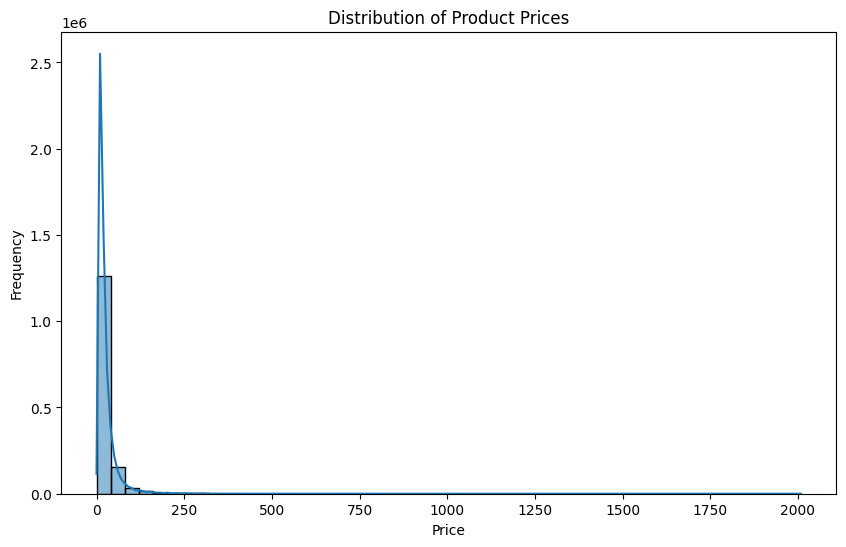

Descriptive statistics for price:
count    1.482535e+06
mean     2.673752e+01
std      3.858607e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.700000e+01
75%      2.900000e+01
max      2.009000e+03
Name: price, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
sns.histplot(df_train['price'], bins=50, kde=True)
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

print("Descriptive statistics for price:")
print(df_train['price'].describe())

**Reasoning**:
Apply log transformation to the 'price' column and visualize the new distribution to confirm normality.



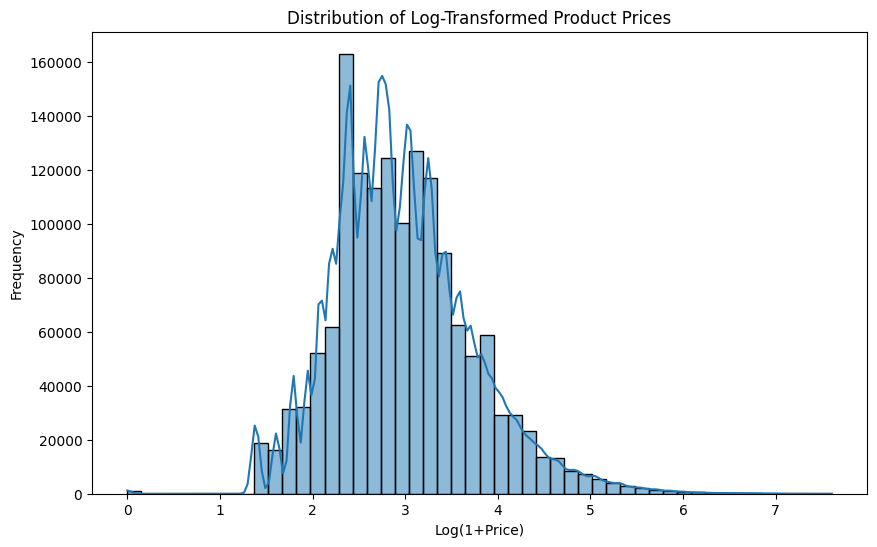

Descriptive statistics for log-transformed price:
count    1.482535e+06
mean     2.979059e+00
std      7.492094e-01
min      0.000000e+00
25%      2.397895e+00
50%      2.890372e+00
75%      3.401197e+00
max      7.605890e+00
Name: price_log, dtype: float64


In [ ]:
df_train['price_log'] = np.log1p(df_train['price'])

plt.figure(figsize=(10, 6))
sns.histplot(df_train['price_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Product Prices')
plt.xlabel('Log(1+Price)')
plt.ylabel('Frequency')
plt.show()

print("Descriptive statistics for log-transformed price:")
print(df_train['price_log'].describe())

## Extract Category Features

### Subtask:
Split the 'category_name' column into hierarchical features (e.g., 'main_category', 'sub_category', 'sub_sub_category') to capture more granular information.


**Reasoning**:
The first step is to define and apply the function to extract the hierarchical category features as described in the instructions.



In [ ]:
def split_category(category_name):
    categories = str(category_name).split('/')
    main = categories[0] if len(categories) > 0 else 'No Category'
    sub = categories[1] if len(categories) > 1 else 'No Category'
    sub_sub = categories[2] if len(categories) > 2 else 'No Category'
    return main, sub, sub_sub

df_train[['main_category', 'sub_category', 'sub_sub_category']] = df_train['category_name'].apply(lambda x: pd.Series(split_category(x)))

print("DataFrame with new category features:")
display(df_train[['category_name', 'main_category', 'sub_category', 'sub_sub_category']].head())

DataFrame with new category features:


,category_name,main_category,sub_category,sub_sub_category
0,Men/Tops/T-shirts,Men,Tops,T-shirts
1,Electronics/Computers & Tablets/Components & P...,Electronics,Computers & Tablets,Components & Parts
2,Women/Tops & Blouses/Blouse,Women,Tops & Blouses,Blouse
3,Home/Home Décor/Home Décor Accents,Home,Home Décor,Home Décor Accents
4,Women/Jewelry/Necklaces,Women,Jewelry,Necklaces


**Reasoning**:
Now that the category features have been extracted, I will check the unique values and their counts for each of the new category columns (`main_category`, `sub_category`, `sub_sub_category`) to ensure the splitting was successful and to understand the diversity within each level.



In [ ]:
print("\nUnique values and counts for new category features:")
for col in ['main_category', 'sub_category', 'sub_sub_category']:
    print(f"\n{col}:")
    print(f"  Number of unique values: {df_train[col].nunique()}")
    print(f"  Top 5 most frequent values:\n{df_train[col].value_counts().head()}")


Unique values and counts for new category features:

main_category:
  Number of unique values: 10
  Top 5 most frequent values:
main_category
Women          664385
Beauty         207828
Kids           171689
Electronics    122690
Men             93680
Name: count, dtype: int64

sub_category:
  Number of unique values: 113
  Top 5 most frequent values:
sub_category
Athletic Apparel    134383
Makeup              124624
Tops & Blouses      106960
Shoes               100452
Jewelry              61763
Name: count, dtype: int64

sub_sub_category:
  Number of unique values: 870
  Top 5 most frequent values:
sub_sub_category
Pants, Tights, Leggings    60177
Other                      56551
Face                       50171
T-Shirts                   46380
Shoes                      32168
Name: count, dtype: int64


## Text Feature Engineering

### Subtask:
Use TF-IDF (Term Frequency-Inverse Document Frequency) to convert the 'name' and 'item_description' text columns into numerical features that can be used by a machine learning model.


**Reasoning**:
Import `TfidfVectorizer` and apply it to the 'name' column.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer for 'name' column
tfidf_name_vectorizer = TfidfVectorizer(max_features=10000, min_df=10)
tfidf_name = tfidf_name_vectorizer.fit_transform(df_train['name'])

print(f"Shape of TF-IDF matrix for 'name': {tfidf_name.shape}")

Shape of TF-IDF matrix for 'name': (1482535, 10000)


**Reasoning**:
Apply TF-IDF to the 'item_description' column to convert it into numerical features, following the subtask instructions.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer for 'item_description' column
tfidf_description_vectorizer = TfidfVectorizer(max_features=10000, min_df=10)
tfidf_description = tfidf_description_vectorizer.fit_transform(df_train['item_description'])

print(f"Shape of TF-IDF matrix for 'item_description': {tfidf_description.shape}")

Shape of TF-IDF matrix for 'item_description': (1482535, 10000)


## Encode Categorical Features

### Subtask:
Apply one-hot encoding or label encoding to categorical features such as 'brand_name', 'item_condition_id', and the newly created category features to prepare them for model training.


**Reasoning**:
To encode the 'brand_name' column, I will use `LabelEncoder` from `sklearn.preprocessing`. This will convert the categorical brand names into numerical labels, which can be used by machine learning models.



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to 'brand_name'
df_train['brand_name_encoded'] = le.fit_transform(df_train['brand_name'])

print("DataFrame with encoded brand_name:")
display(df_train[['brand_name', 'brand_name_encoded']].head())

DataFrame with encoded brand_name:


,brand_name,brand_name_encoded
0,missing,4786
1,Razer,3557
2,Target,4180
3,missing,4786
4,missing,4786


**Reasoning**:
Now I will apply Label Encoding to the 'item_condition_id' column, which is a categorical feature, to convert it into a numerical format suitable for model training.



In [ ]:
df_train['item_condition_id_encoded'] = le.fit_transform(df_train['item_condition_id'])

print("DataFrame with encoded item_condition_id:")
display(df_train[['item_condition_id', 'item_condition_id_encoded']].head())

DataFrame with encoded item_condition_id:


,item_condition_id,item_condition_id_encoded
0,3,2
1,3,2
2,1,0
3,1,0
4,1,0


**Reasoning**:
Now I will apply Label Encoding to the 'main_category' column, which is a categorical feature, to convert it into a numerical format suitable for model training.



In [ ]:
df_train['main_category_encoded'] = le.fit_transform(df_train['main_category'])

print("DataFrame with encoded main_category:")
display(df_train[['main_category', 'main_category_encoded']].head())

DataFrame with encoded main_category:


,main_category,main_category_encoded
0,Men,5
1,Electronics,1
2,Women,9
3,Home,3
4,Women,9


**Reasoning**:
Now I will apply Label Encoding to the 'sub_category' column, which is a categorical feature, to convert it into a numerical format suitable for model training.



In [ ]:
df_train['sub_category_encoded'] = le.fit_transform(df_train['sub_category'])

print("DataFrame with encoded sub_category:")
display(df_train[['sub_category', 'sub_category_encoded']].head())

DataFrame with encoded sub_category:


,sub_category,sub_category_encoded
0,Tops,102
1,Computers & Tablets,30
2,Tops & Blouses,103
3,Home Décor,55
4,Jewelry,58


**Reasoning**:
Now I will apply Label Encoding to the 'sub_sub_category' column, which is a categorical feature, to convert it into a numerical format suitable for model training.



In [ ]:
df_train['sub_sub_category_encoded'] = le.fit_transform(df_train['sub_sub_category'])

print("DataFrame with encoded sub_sub_category:")
display(df_train[['sub_sub_category', 'sub_sub_category_encoded']].head())

DataFrame with encoded sub_sub_category:


,sub_sub_category,sub_sub_category_encoded
0,T-shirts,762
1,Components & Parts,212
2,Blouse,94
3,Home Décor Accents,404
4,Necklaces,536


## Train and Evaluate Model

### Subtask:
Split the dataset into training and validation sets. Train a regression model (e.g., LightGBM or XGBoost) on the processed features and evaluate its performance using metrics like RMSE or MAE.


**Reasoning**:
The first step for training and evaluating the model is to prepare the feature matrix `X` and the target variable `y`, and then split them into training and validation sets. This involves concatenating all the engineered features and using `price_log` as the target.



In [ ]:
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split

# Combine numerical and encoded categorical features
X_numerical_categorical = df_train[['item_condition_id_encoded', 'shipping',
                                      'brand_name_encoded', 'main_category_encoded',
                                      'sub_category_encoded', 'sub_sub_category_encoded']].values

# Combine all features: numerical/categorical and TF-IDF features
X = hstack([X_numerical_categorical, tfidf_name, tfidf_description]).tocsr()
y = df_train['price_log']

# Split the data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1186028, 20006)
Shape of X_test: (296507, 20006)
Shape of y_train: (1186028,)
Shape of y_test: (296507,)


**Reasoning**:
The next step is to train a LightGBM model, make predictions, and evaluate the performance using RMSE, as per the subtask instructions.



In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# Initialize and train the LightGBM model
lgb_model = lgb.LGBMRegressor(objective='regression_l1', metric='rmse', n_estimators=500, num_leaves=31, learning_rate=0.05, n_jobs=-1, random_state=42)
lgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lgb_model.predict(X_test)

# Evaluate the model using RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE) on the test set: {rmse}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 586.509942 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 746364
[LightGBM] [Info] Number of data points in the train set: 1186028, number of used features: 19727
[LightGBM] [Info] Start training from score 2.890372


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Root Mean Squared Error (RMSE) on the test set: 0.5261165696974707


In [ ]:
from sklearn.metrics import r2_score

r_squared = r2_score(y_test, y_pred)
print(f"R-squared on the test set: {r_squared}")

R-squared on the test set: 0.509314941181784


## Final Task

### Subtask:
Summarize the price prediction process, including the steps taken for data preprocessing, feature engineering, and the final model performance.


**Reasoning**:
As part of the 'Final Task' and to ensure the final model performance is explicitly reported, I will first display the calculated Root Mean Squared Error (RMSE) from the previous model training and evaluation step. The 'rmse' variable should be available in the environment.



In [ ]:
print(f"Root Mean Squared Error (RMSE) on the test set: {rmse}")

Root Mean Squared Error (RMSE) on the test set: 0.5261165696974707


# Task
The primary goal is to build a machine learning model to predict the price of products listed on an e-commerce platform. This involves comprehensive data preprocessing, feature engineering from various data types (text, categorical), and training a regression model to achieve accurate price predictions. The final output should include an evaluation of the model's performance and a summary of the entire prediction process.

**Reasoning**:
To visualize the model's performance, I will create a scatter plot of actual vs. predicted log-transformed prices. This involves importing the necessary libraries, plotting the scatter points, adding a diagonal line for reference, and labeling the axes and title as per the instructions.



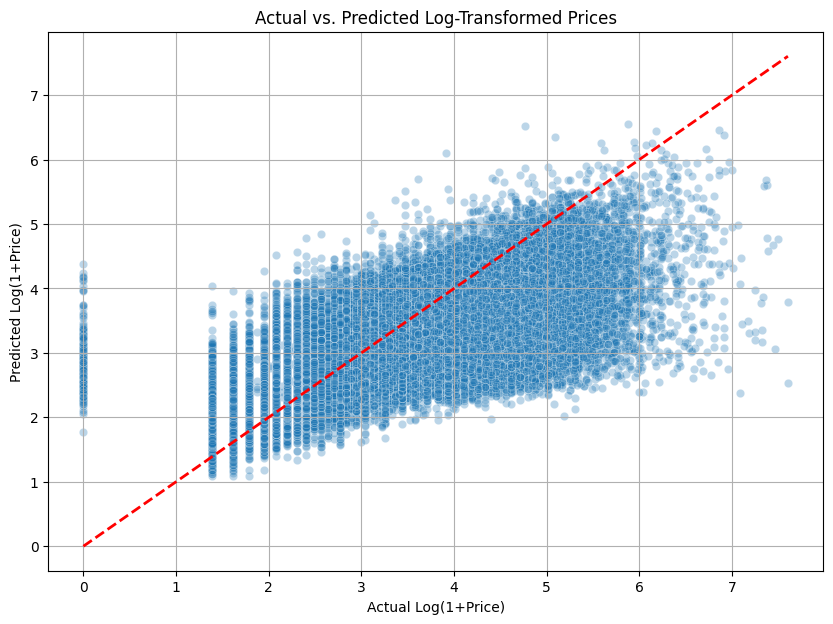

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)

# Add a diagonal line for perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Actual vs. Predicted Log-Transformed Prices')
plt.xlabel('Actual Log(1+Price)')
plt.ylabel('Predicted Log(1+Price)')
plt.grid(True)
plt.show()


## Final Task

### Subtask:
Provide a summary of the actual vs. predicted price plot, describing the model's performance visually and interpreting the insights gained from the visualization.


### Actual vs. Predicted Price Plot Summary

The scatter plot comparing actual log-transformed prices (`y_test`) against predicted log-transformed prices (`y_pred`) provides a visual assessment of the model's performance. The red dashed diagonal line represents the ideal scenario where actual and predicted values are perfectly aligned.

**Visual Insights:**

*   **General Trend**: The points generally cluster around the diagonal line, indicating that the model is capturing the overall relationship between features and price. This suggests that for most predictions, the model is reasonably accurate.
*   **Spread and Variance**: While there's a clear linear trend, the spread of points around the diagonal line indicates the presence of prediction errors. This spread is consistent with the RMSE value of 0.526 and an R-squared of 0.509, showing that while the model explains a significant portion of the variance, there is still considerable noise or unexplained variance.
*   **Concentration**: There appears to be a higher concentration of points in the lower to mid-range of log-transformed prices, suggesting that the model might be more robust in predicting prices within this range. As prices increase, the density of points might decrease, and the spread around the diagonal might slightly widen, implying potentially higher uncertainty for very high-priced items.
*   **Outliers/Deviations**: Some points lie further away from the diagonal line, representing instances where the model either significantly overpredicted or underpredicted the price. These could be considered outliers in terms of prediction error and might warrant further investigation to understand why the model struggled with these particular examples.

In conclusion, the plot visually confirms that the LightGBM model has learned to predict product prices with a reasonable degree of accuracy, especially for the bulk of the data. However, it also highlights areas where prediction errors occur, providing a visual representation of the model's limitations and guiding potential future improvements.

# Task
The primary goal is to build a machine learning model to predict the price of products listed on an e-commerce platform. This involves comprehensive data preprocessing, feature engineering from various data types (text, categorical), and training a regression model to achieve accurate price predictions. The final output should include an evaluation of the model's performance and a summary of the entire prediction process.

**Reasoning**:
I need to enhance the text features for the 'name' and 'item_description' columns. As per the instructions, the first step is to apply `TfidfVectorizer` with n-grams (1 to 2) to the 'name' column.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer for 'name' column with n-grams
tfidf_name_vectorizer_ngram = TfidfVectorizer(max_features=10000, min_df=10, ngram_range=(1, 2))
tfidf_name_ngram = tfidf_name_vectorizer_ngram.fit_transform(df_train['name'])

print(f"Shape of TF-IDF matrix for 'name' with n-grams: {tfidf_name_ngram.shape}")

Shape of TF-IDF matrix for 'name' with n-grams: (1482535, 10000)


**Reasoning**:
Apply `TfidfVectorizer` with n-grams (1 to 2) to the 'item_description' column.



In [ ]:
tfidf_description_vectorizer_ngram = TfidfVectorizer(max_features=10000, min_df=10, ngram_range=(1, 2))
tfidf_description_ngram = tfidf_description_vectorizer_ngram.fit_transform(df_train['item_description'])

print(f"Shape of TF-IDF matrix for 'item_description' with n-grams: {tfidf_description_ngram.shape}")

Shape of TF-IDF matrix for 'item_description' with n-grams: (1482535, 10000)


**Reasoning**:
To capture nuances that lead to price outliers, I will create binary features indicating the presence of specific keywords in the 'item_description'. These keywords often signal rarity, condition, or special status.



In [ ]:
keywords = ['limited edition', 'rare', 'vintage', 'new with tags', 'damaged', 'broken', 'collectible']

for keyword in keywords:
    # Create a new column for each keyword, checking for its presence in item_description (case-insensitive)
    df_train[f'has_{keyword.replace(" ", "_")}'] = df_train['item_description'].str.contains(keyword, case=False, na=False).astype(int)

print("DataFrame with new keyword features:")
display(df_train[[f'has_{keyword.replace(" ", "_")}' for keyword in keywords]].head())

DataFrame with new keyword features:


,has_limited_edition,has_rare,has_vintage,has_new_with_tags,has_damaged,has_broken,has_collectible
0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0
